# DS 592 Homework 6 — Coding Assignment

## Linear Bandits: OFUL Algorithm

##### Sulaf Al Jabal U78815065 


1. $\mathcal{A}_t = B_d(0,1)$ (unit ball) for $d=5$ and $d=10$
2. $\mathcal{A}_t = \{-1,1\}^5$ (hypercube), compared against MAB-UCB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iterproduct

np.random.seed(592)
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

In [2]:
def compute_beta(t, d, lam, S, L, delta):
    """textbook reference"""
    sqrt_beta = np.sqrt(lam) * S + np.sqrt(2 * np.log(1 / delta) + d * np.log(1 + t * L**2 / (lam * d)))
    return sqrt_beta ** 2

### OFUL for continuous action set (unit ball)

In [3]:
def oful_ball_action(theta_hat, Sigma_inv, sqrt_beta, d, n_candidates=500):

    #Random candidates on ball
    candidates = np.random.randn(n_candidates, d)
    candidates /= np.linalg.norm(candidates, axis=1, keepdims=True)
    
    #confidence ellipsoid
    eigvals, eigvecs = np.linalg.eigh(Sigma_inv)
    structured = []
    
    # eigenvectors  (both signs)
    for i in range(d):
        structured.append(eigvecs[:, i])
        structured.append(-eigvecs[:, i])
    
    # theta_hat direction
    th_norm = np.linalg.norm(theta_hat)
    if th_norm > 1e-12:
        structured.append(theta_hat / th_norm)
    
    # Sigma_inv @ theta_hat direction ('hint' from optimism)
    hint = Sigma_inv @ theta_hat
    hint_norm = np.linalg.norm(hint)
    if hint_norm > 1e-12:
        structured.append(hint / hint_norm)
    
    # Linear combinations of theta_hat direction and top eigenvectors
    if th_norm > 1e-12:
        e_th = theta_hat / th_norm
        for i in range(min(3, d)):  # top 3 eigenvectors
            ev = eigvecs[:, -(i+1)]
            for alpha in np.linspace(0, 1, 10):
                combo = alpha * e_th + (1 - alpha) * ev
                cn = np.linalg.norm(combo)
                if cn > 1e-12:
                    structured.append(combo / cn)
                combo2 = alpha * e_th - (1 - alpha) * ev
                cn2 = np.linalg.norm(combo2)
                if cn2 > 1e-12:
                    structured.append(combo2 / cn2)
    
    if structured:
        structured = np.array(structured)
        candidates = np.vstack([candidates, structured])
    
    # evaluate UCB for all candidates: shape (n_cand,)
    est_reward = candidates @ theta_hat
    bonus = np.sqrt(np.einsum('ij,jk,ik->i', candidates, Sigma_inv, candidates))
    ucb_vals = est_reward + sqrt_beta * bonus
    
    return candidates[np.argmax(ucb_vals)]

In [4]:
def oful_ball(d, n, theta_star, lam=1.0, delta=0.01, n_sims=20, n_candidates=300):

    S = np.linalg.norm(theta_star)
    L = 1.0  # ||a||_2 <= 1 on the ball
    
    # Optimal reward: max_{||a||<=1} <a, theta_star> = ||theta_star||
    r_star = S
    
    regret_curves = np.zeros((n_sims, n))
    
    for sim in range(n_sims):
        Sigma = lam * np.eye(d) # (d, d)
        b = np.zeros(d) # sum of a_s * r_s
        
        cum_regret = 0.0
        for t in range(n):
            Sigma_inv = np.linalg.inv(Sigma)
            theta_hat = Sigma_inv @ b
            beta_t = compute_beta(t, d, lam, S, L, delta)
            sqrt_beta = np.sqrt(beta_t)
            
            # Select action
            a_t = oful_ball_action(theta_hat, Sigma_inv, sqrt_beta, d, n_candidates)
            
            # Observe reward
            reward = a_t @ theta_star + np.random.randn()
            
            # Update
            Sigma += np.outer(a_t, a_t)
            b += a_t * reward
            
            # Track regret
            instant_regret = r_star - (a_t @ theta_star)
            cum_regret += instant_regret
            regret_curves[sim, t] = cum_regret
    
    return regret_curves

### OFUL for finite action set


In [5]:
def oful_finite(actions, n, theta_star, lam=1.0, delta=0.01, n_sims=20):
    
    K, d = actions.shape
    S = np.linalg.norm(theta_star)
    L = np.max(np.linalg.norm(actions, axis=1))
    
    # Optimal reward
    rewards_all = actions @ theta_star  # (K,)
    r_star = rewards_all.max()
    
    regret_curves = np.zeros((n_sims, n))
    
    # Sigma: (n_sims, d, d), b: (n_sims, d)
    Sigma = np.tile(lam * np.eye(d), (n_sims, 1, 1)) # (n_sims, d, d)
    b_vec = np.zeros((n_sims, d)) # (n_sims, d)
    cum_regret = np.zeros(n_sims)
    
    for t in range(n):
        # Compute Sigma_inv and theta_hat for all sims
        Sigma_inv = np.linalg.inv(Sigma) # (n_sims, d, d)
        theta_hat = np.einsum('sij,sj->si', Sigma_inv, b_vec)# (n_sims, d)
        
        beta_t = compute_beta(t, d, lam, S, L, delta)
        sqrt_beta = np.sqrt(beta_t)
        
        # Compute UCB for all actions and all sims
        # est_reward: (n_sims, K) = theta_hat (n_sims, d) @ actions.T (d, K)
        est_reward = theta_hat @ actions.T # (n_sims, K)
        
        # bonus: ||a||_{Sigma_inv} for each action and sim
        # actions: (K, d), Sigma_inv: (n_sims, d, d)
        # a^T Sigma_inv a for each (sim, action): use einsum
        # (K, d) @ (n_sims, d, d) --> need: for each sim s, for each action k: actions[k] @ Sigma_inv[s] @ actions[k]??
        # = einsum('kd, sde, ke --> sk', actions, Sigma_inv, actions)
        bonus_sq = np.einsum('kd,sde,ke->sk', actions, Sigma_inv, actions)  # (n_sims, K)
        bonus = np.sqrt(np.maximum(bonus_sq, 0)) # (n_sims, K)
        
        ucb_vals = est_reward + sqrt_beta * bonus  # (n_sims, K)
        chosen = np.argmax(ucb_vals, axis=1) # (n_sims,)
        
        # Get the chosen action vectors
        a_chosen = actions[chosen]# (n_sims, d)
        
        # Generate noisy rewards
        noise = np.random.randn(n_sims)
        rewards = np.sum(a_chosen * theta_star, axis=1) + noise  # (n_sims,)
        
        # Update Sigma and b for all sims
        # Sigma[s] += outer(a_chosen[s], a_chosen[s])
        Sigma += np.einsum('si,sj->sij', a_chosen, a_chosen)  # (n_sims, d, d)
        b_vec += a_chosen * rewards[:, None] # (n_sims, d)
        
        # Track regret
        instant_regret = r_star - np.sum(a_chosen * theta_star, axis=1)  # (n_sims,)
        cum_regret += instant_regret
        regret_curves[:, t] = cum_regret
    
    return regret_curves

### UCB for Multi-Armed Bandits (baseline for Experiment 2)

Standard UCB treating each of the $K = 2^5 = 32$ actions as an independent arm.

In [6]:
def ucb_mab(actions, n, theta_star, n_sims=20):

    K, d = actions.shape
    true_rewards = actions @ theta_star # (K,) mean reward of each "arm"
    r_star = true_rewards.max()
    
    N = np.zeros((n_sims, K)) # pull counts
    Sum = np.zeros((n_sims, K))# sum of observed rewards
    cum_regret = np.zeros(n_sims)
    regret_curves = np.zeros((n_sims, n))
    
    for t in range(1, n + 1):
        if t <= K:
            # Initialization: pull each arm once
            chosen = np.full(n_sims, t - 1, dtype=int)
        else:
            # UCB rule with f(t) = 1 + t*(log t)^2
            f_t = 1.0 + t * (np.log(t)) ** 2
            mu_hat = Sum / np.maximum(N, 1)# (n_sims, K)
            # rewards are <a, theta*> + noise, noise is N(0,1) so 1-subgaussian
            bonus = np.sqrt(2 * np.log(f_t) / np.maximum(N, 1))  # (n_sims, K)
            ucb_vals = mu_hat + bonus
            chosen = np.argmax(ucb_vals, axis=1)# (n_sims,)
        
        #observe rewards
        mean_r = true_rewards[chosen]# (n_sims,)
        noise = np.random.randn(n_sims)
        rewards = mean_r + noise
        
        #update
        np.add.at(N, (np.arange(n_sims), chosen), 1)
        np.add.at(Sum, (np.arange(n_sims), chosen), rewards)
        
        # Regret
        cum_regret += r_star - mean_r
        regret_curves[:, t - 1] = cum_regret
    
    return regret_curves

---
## Experiment 1: Unit Ball Action Set ($d = 5$ and $d = 10$)

horizon $n = 10000$ to demonstrate sublinear regret.

In [7]:
n_sims = 15

# d = 5
d5 = 5
theta_star_5 = np.random.randn(d5)
theta_star_5 = theta_star_5 / np.linalg.norm(theta_star_5)#

n5 = 10000
print(f"Running OFUL on B_{{5}}(0,1) with n={n5}, {n_sims} sims...")
regret_ball_5 = oful_ball(d5, n5, theta_star_5, lam=1.0, delta=0.01, n_sims=n_sims, n_candidates=400)
print("Done.")

Running OFUL on B_{5}(0,1) with n=10000, 15 sims...
Done.


In [8]:
# d = 10
d10 = 10
theta_star_10 = np.random.randn(d10)
theta_star_10 = theta_star_10 / np.linalg.norm(theta_star_10)  # unit norm

n10 = 10000
print(f"Running OFUL on B_{{10}}(0,1) with n={n10}, {n_sims} sims...")
regret_ball_10 = oful_ball(d10, n10, theta_star_10, lam=1.0, delta=0.01, n_sims=n_sims, n_candidates=600)
print("Done.")

Running OFUL on B_{10}(0,1) with n=10000, 15 sims...
Done.


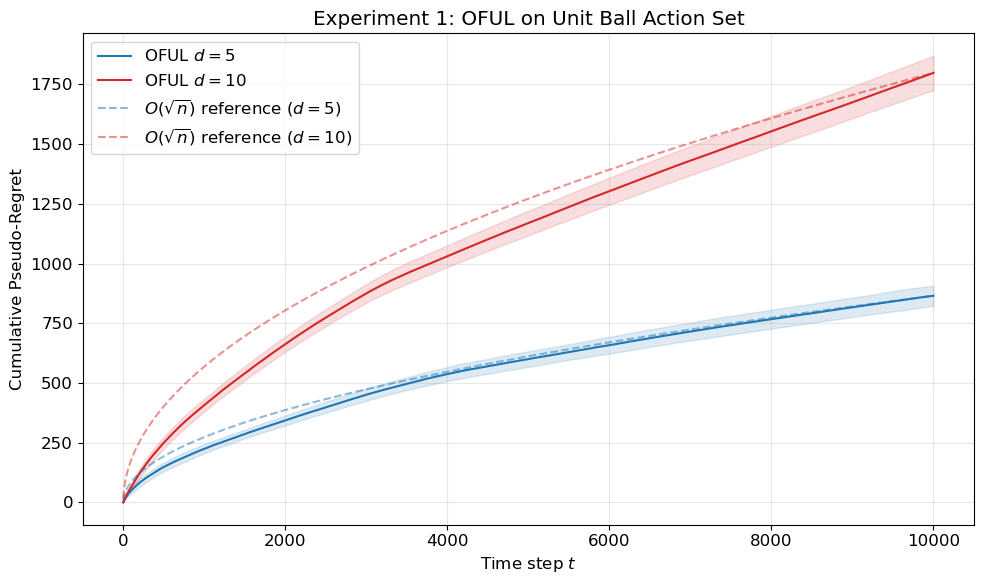

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ts5 = np.arange(1, n5 + 1)
ts10 = np.arange(1, n10 + 1)

mean5 = regret_ball_5.mean(axis=0)
std5 = regret_ball_5.std(axis=0)

mean10 = regret_ball_10.mean(axis=0)
std10 = regret_ball_10.std(axis=0)

ax.plot(ts5, mean5, label=f'OFUL $d=5$', color='tab:blue')
ax.fill_between(ts5, mean5 - std5, mean5 + std5, alpha=0.15, color='tab:blue')

ax.plot(ts10, mean10, label=f'OFUL $d=10$', color='tab:red')
ax.fill_between(ts10, mean10 - std10, mean10 + std10, alpha=0.15, color='tab:red')

# Plot sqrt(n) reference curves
c5 = mean5[-1] / np.sqrt(n5)
c10 = mean10[-1] / np.sqrt(n10)
ax.plot(ts5, c5 * np.sqrt(ts5), '--', color='tab:blue', alpha=0.5, label=r'$O(\sqrt{n})$ reference ($d=5$)')
ax.plot(ts10, c10 * np.sqrt(ts10), '--', color='tab:red', alpha=0.5, label=r'$O(\sqrt{n})$ reference ($d=10$)')

ax.set_xlabel('Time step $t$')
ax.set_ylabel('Cumulative Pseudo-Regret')
ax.set_title('Experiment 1: OFUL on Unit Ball Action Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('experiment1_ball_regret.png', dpi=150)
plt.show()

---
## Experiment 2: Finite Action Set $\{-1,1\}^5$ — OFUL vs UCB

The action set is $\mathcal{A} = \{-1,1\}^5$, which has $K = 2^5 = 32$ actions in $\mathbb{R}^5$.

Comparisons:
- **OFUL** (linear bandits): exploits the 5-dimensional linear structure, regret $\tilde{O}(d\sqrt{n}) = \tilde{O}(5\sqrt{n})$.
- **UCB** (MAB): treats all 32 arms independently, regret $\tilde{O}(\sqrt{Kn}) = \tilde{O}(\sqrt{32n})$.


In [10]:
# Build action set {-1, 1}^5
d = 5
action_list = np.array(list(iterproduct([-1, 1], repeat=d)), dtype=float)  # (32, 5)
K = action_list.shape[0]
print(f"Action set size: K = {K}, dimension: d = {d}")

theta_star_hyp = np.random.randn(d)
theta_star_hyp = theta_star_hyp / np.linalg.norm(theta_star_hyp) * 0.3  # moderate norm
print(f"theta* = {theta_star_hyp}")
print(f"||theta*|| = {np.linalg.norm(theta_star_hyp):.4f}")
print(f"Optimal reward = {np.max(action_list @ theta_star_hyp):.4f}")

Action set size: K = 32, dimension: d = 5
theta* = [ 0.19221852 -0.07063852 -0.06110033 -0.16672569  0.128575  ]
||theta*|| = 0.3000
Optimal reward = 0.6193


In [11]:
n_exp2 = 20000
n_sims_exp2 = 30

print(f"Running OFUL on {{-1,1}}^5 with n={n_exp2}, {n_sims_exp2} sims...")
regret_oful = oful_finite(action_list, n_exp2, theta_star_hyp, lam=1.0, delta=0.01, n_sims=n_sims_exp2)
print("Done.")

print(f"Running UCB on {{-1,1}}^5 with n={n_exp2}, {n_sims_exp2} sims...")
regret_ucb = ucb_mab(action_list, n_exp2, theta_star_hyp, n_sims=n_sims_exp2)
print("Done.")

Running OFUL on {-1,1}^5 with n=20000, 30 sims...
Done.
Running UCB on {-1,1}^5 with n=20000, 30 sims...
Done.


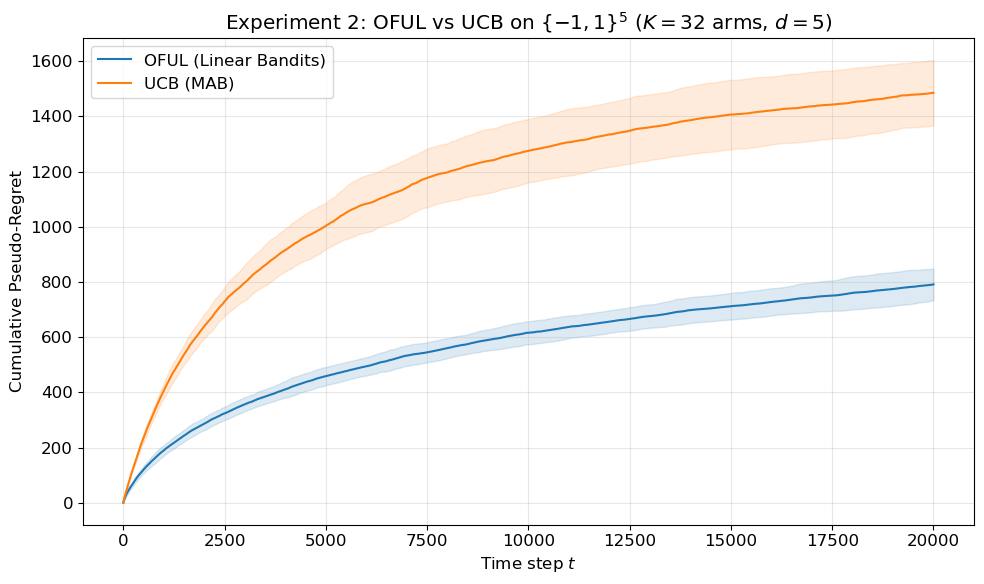

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ts = np.arange(1, n_exp2 + 1)

mean_oful = regret_oful.mean(axis=0)
std_oful = regret_oful.std(axis=0)

mean_ucb = regret_ucb.mean(axis=0)
std_ucb = regret_ucb.std(axis=0)

ax.plot(ts, mean_oful, label='OFUL (Linear Bandits)', color='tab:blue')
ax.fill_between(ts, mean_oful - std_oful, mean_oful + std_oful, alpha=0.15, color='tab:blue')

ax.plot(ts, mean_ucb, label='UCB (MAB)', color='tab:orange')
ax.fill_between(ts, mean_ucb - std_ucb, mean_ucb + std_ucb, alpha=0.15, color='tab:orange')

ax.set_xlabel('Time step $t$')
ax.set_ylabel('Cumulative Pseudo-Regret')
ax.set_title(r'Experiment 2: OFUL vs UCB on $\{-1,1\}^5$ ($K=32$ arms, $d=5$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('experiment2_oful_vs_ucb.png', dpi=150)
plt.show()

In [13]:
print(f"Final regret at t = {n_exp2}:")
print(f"  OFUL: {mean_oful[-1]:.1f} ± {std_oful[-1]:.1f}")
print(f"  UCB:  {mean_ucb[-1]:.1f} ± {std_ucb[-1]:.1f}")
print(f"  Ratio UCB/OFUL: {mean_ucb[-1]/mean_oful[-1]:.2f}x")

Final regret at t = 20000:
  OFUL: 791.4 ± 56.9
  UCB:  1485.6 ± 118.3
  Ratio UCB/OFUL: 1.88x


**Observation:** OFUL achieves lower cumulative regret than UCB. UCB treats each of the 32 arms independently and must explore each one separately, but OFUL learns the 5-dimensional parameter $\theta^*$ and can generalize across arms. Both algorithms exhibit sublinear regret growth. This confirms the theoretical guarantees.